In [1]:
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service as ChromeService
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager

# --- Setup Selenium WebDriver ---
options = Options()
options.add_argument("--headless")  # Run in background without opening a browser window
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")

# Use webdriver-manager to automatically handle the driver
service = ChromeService(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=options)

base_url = "https://books.toscrape.com/"
all_books_data = [] # This list will store all our data

try:
    print("Starting browser and navigating to main page...")
    driver.get(base_url)
    
    # --- 1. Extract all category links ---
    category_elements = driver.find_elements(By.CSS_SELECTOR, "ul.nav-list > li > ul > li > a")
    categories = []
    for elem in category_elements:
        categories.append({
            'name': elem.text.strip(),
            'url': elem.get_attribute('href')
        })
    
    print(f"Found {len(categories)} categories.")

    # --- 2. Loop through each category and handle pagination ---
    for category in categories:
        print(f"Scraping category: {category['name']}...")
        current_url = category['url']
        
        while True:
            driver.get(current_url)
            
            # Find all books on the current page
            books_on_page = driver.find_elements(By.CSS_SELECTOR, "article.product_pod")
            
            # Add a record for each book found
            for book in books_on_page:
                all_books_data.append({'category': category['name']})
            
            # --- 3. Handle pagination ---
            try:
                # Find the 'next' button
                next_button = driver.find_element(By.CSS_SELECTOR, "li.next > a")
                # Get the URL for the next page
                current_url = next_button.get_attribute('href')
            except Exception as e:
                # No 'next' button found, this is the last page
                # print(f"  Reached last page for {category['name']}.")
                break # Exit the while loop and go to the next category

    print("Scraping complete!")

finally:
    # --- 4. Clean up and close the browser ---
    driver.quit()
    print("Browser closed.")

# --- 5. Organize the data into a DataFrame ---
df_all_books = pd.DataFrame(all_books_data)

print(f"\nTotal books scraped: {len(df_all_books)}")
print("DataFrame head:")
print(df_all_books.head())

Starting browser and navigating to main page...
Found 50 categories.
Scraping category: Travel...
Scraping category: Mystery...
Scraping category: Historical Fiction...
Scraping category: Sequential Art...
Scraping category: Classics...
Scraping category: Philosophy...
Scraping category: Romance...
Scraping category: Womens Fiction...
Scraping category: Fiction...
Scraping category: Childrens...
Scraping category: Religion...
Scraping category: Nonfiction...
Scraping category: Music...
Scraping category: Default...
Scraping category: Science Fiction...
Scraping category: Sports and Games...
Scraping category: Add a comment...
Scraping category: Fantasy...
Scraping category: New Adult...
Scraping category: Young Adult...
Scraping category: Science...
Scraping category: Poetry...
Scraping category: Paranormal...
Scraping category: Art...
Scraping category: Psychology...
Scraping category: Autobiography...
Scraping category: Parenting...
Scraping category: Adult Fiction...
Scraping catego

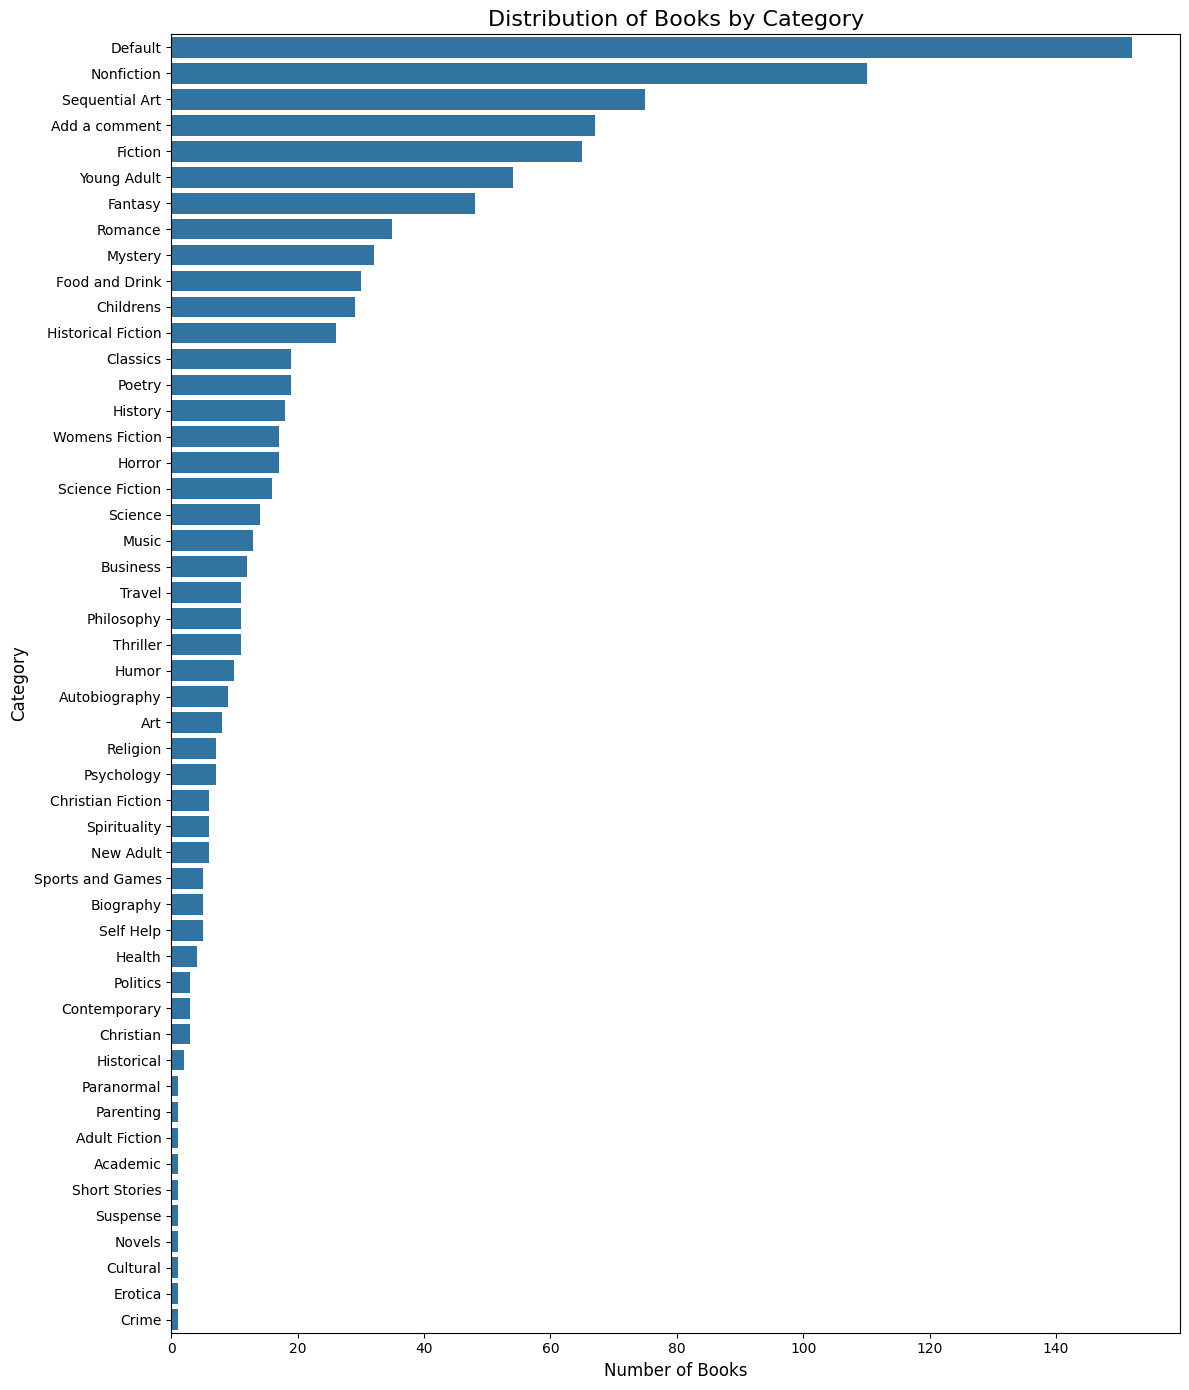

In [2]:
# --- 6. Visualize the distribution of books by category ---

# Check if the DataFrame is empty
if not df_all_books.empty:
    plt.figure(figsize=(12, 14))
    
    # Use seaborn.countplot
    # We set y='category' to create a horizontal bar chart
    # 'order' sorts the bars from most frequent to least frequent
    sns.countplot(
        data=df_all_books, 
        y='category', 
        order=df_all_books['category'].value_counts().index
    )
    
    plt.title('Distribution of Books by Category', fontsize=16)
    plt.xlabel('Number of Books', fontsize=12)
    plt.ylabel('Category', fontsize=12)
    plt.tight_layout() # Adjusts plot to prevent labels from overlapping
    plt.show()
else:
    print("The DataFrame is empty. No data to plot.")